### Proposing Interactive Jupyter Notebook 1: "The Axiom Verifier"

To help internalize these rules, I propose a notebook that focuses on the **Linearity** and **Closure** of signal spaces.

*   **Visualization: Signal Superposition.** Create a widget where you can select two signals, $x[n]$ (e.g., a sine wave) and $y[n]$ (e.g., noise). Allow the user to adjust sliders for $\alpha$ and $\beta$ to observe the resulting vector $z[n] = \alpha x[n] + \beta y[n]$. 
*   **Verification Logic.** Write a small script that takes a user-defined "set" of signals and checks if they are closed under addition. For instance, if the set is "all signals with values between 0 and 1," does it form a vector space? (Hint: No, because scaling by -1 leaves the set).
*   **The Zero Signal.** Plot the additive identity for various spaces: a vector of zeros for $\mathbb{C}^N$ and a function $x(t) = 0$ for $L^2(\mathbb{R})$.

---

### Proposing Interactive Jupyter Notebook 2: "The Subspace Navigator"

This notebook will focus on the concept of **Linear Combinations** and **Geometric Translation**.

*   **Visualization 1: Subspace vs. Affine.** Create a 3D plot. Define a plane $S$ passing through $(0,0,0)$. This is your subspace. Use a slider to define a translation vector $x$. Watch the plane $S$ shift into an affine subspace $T = x + S$.
*   **Visualization 2: Signal Synthesis.** Use the **Haar wavelet** basis. Show that by taking different linear combinations of specific wavelet "shapes" (basis vectors), the resulting signal stays within the **span** of those vectors, effectively navigating within a specific subspace of $L^2$.
*   **Constraint Checking:** Provide a tool where the user inputs a "rule" (e.g., "signals where the first sample is twice the second"). The notebook will then test if this set is closed under addition and scaling to determine if it is a subspace.

---

### Proposing Interactive Jupyter Notebook 3: "The Geometry of Independence"

*   **Visualization 1: The Zero-Vector Game.** In a 3D coordinate system, provide the user with two fixed vectors. Allow the user to drag a third vector. Highlight in real-time if the third vector lies in the **span** of the first two. If it does, find the scalars $\alpha_1, \alpha_2$ such that $\alpha_1 \phi_1 + \alpha_2 \phi_2 = \phi_3$, demonstrating dependency.
*   **Visualization 2: Redundant Fourier Bases.** Take a 4-point signal. Use the 4 standard DFT basis vectors and then add a 5th "random" vector. Show how the same signal can now be represented by **infinitely many different sets of coefficients**, illustrating the loss of uniqueness in redundant frames.
*   **Thought Experiment:** If you have a 3D space, can you find 4 vectors that *don't* span it? Can you find 2 vectors that *do* span it?

---

# The Signal Plane: Geometric Perspectives on DSP

This notebook explores geometric abstractions in signal processing by treating small sequences as vectors in 2D and 3D space. We'll visualize:

1. **Similarity and Orthogonality**: Interactive exploration of inner products and angles between vectors
2. **Norm Shapes**: How different p-norms define "distance" in signal space
3. **Noise and Distance**: The relationship between signal distance and signal-to-noise ratio (SNR)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

## Visualization 1: Similarity and Orthogonality

In signal processing, the **inner product** between two signals measures their similarity:

$$\langle x, y \rangle = \sum_{n} x[n] \cdot y[n]$$

The **angle** $\theta$ between two vectors is defined by:

$$\cos\theta = \frac{\langle x, y \rangle}{\|x\| \cdot \|y\|}$$

Special cases:
- $\theta = 0°$: Vectors are perfectly aligned (maximum similarity)
- $\theta = 90°$: Vectors are **orthogonal** (no correlation)
- $\theta = 180°$: Vectors are anti-aligned (negative correlation)

In [5]:
def create_interactive_vectors():
    """
    Create an interactive plot where you can drag two vectors and see
    their inner product and angle in real-time.
    """
    # Initial vector coordinates
    x_init = np.array([3, 2])
    y_init = np.array([1, 3])
    
    fig = go.FigureWidget()
    
    # Add vector x (red arrow)
    fig.add_trace(go.Scatter(
        x=[0, x_init[0]], y=[0, x_init[1]],
        mode='lines+markers',
        name='Vector x',
        line=dict(color='red', width=3),
        marker=dict(size=[0, 15], color='red')
    ))
    
    # Add vector y (blue arrow)
    fig.add_trace(go.Scatter(
        x=[0, y_init[0]], y=[0, y_init[1]],
        mode='lines+markers',
        name='Vector y',
        line=dict(color='blue', width=3),
        marker=dict(size=[0, 15], color='blue')
    ))
    
    # Calculate initial metrics
    def compute_metrics(x_vec, y_vec):
        inner_prod = np.dot(x_vec, y_vec)
        norm_x = np.linalg.norm(x_vec)
        norm_y = np.linalg.norm(y_vec)
        
        if norm_x > 0 and norm_y > 0:
            cos_theta = inner_prod / (norm_x * norm_y)
            cos_theta = np.clip(cos_theta, -1, 1)  # Numerical stability
            theta_rad = np.arccos(cos_theta)
            theta_deg = np.degrees(theta_rad)
        else:
            theta_deg = 0
            
        return inner_prod, theta_deg, norm_x, norm_y
    
    inner_prod, theta_deg, norm_x, norm_y = compute_metrics(x_init, y_init)
    
    # Add annotation for metrics
    annotation_text = (
        f"<b>Inner Product:</b> ⟨x,y⟩ = {inner_prod:.3f}<br>"
        f"<b>Angle:</b> θ = {theta_deg:.1f}°<br>"
        f"<b>Norms:</b> ‖x‖ = {norm_x:.3f}, ‖y‖ = {norm_y:.3f}"
    )
    
    fig.add_annotation(
        x=0.02, y=0.98,
        xref="paper", yref="paper",
        text=annotation_text,
        showarrow=False,
        bgcolor="white",
        bordercolor="black",
        borderwidth=1,
        xanchor="left",
        yanchor="top",
        font=dict(size=12)
    )
    
    # Update function when vectors are dragged
    def update_vectors(trace, points, selector):
        if points.point_inds:
            # Get the trace index (0 for x, 1 for y)
            trace_idx = 0 if trace.line.color == 'red' else 1
            
            # Get new coordinates
            new_x = points.xs[0]
            new_y = points.ys[0]
            
            # Update the trace
            with fig.batch_update():
                fig.data[trace_idx].x = [0, new_x]
                fig.data[trace_idx].y = [0, new_y]
                
                # Get both vectors
                x_vec = np.array([fig.data[0].x[1], fig.data[0].y[1]])
                y_vec = np.array([fig.data[1].x[1], fig.data[1].y[1]])
                
                # Recompute metrics
                inner_prod, theta_deg, norm_x, norm_y = compute_metrics(x_vec, y_vec)
                
                # Update annotation
                annotation_text = (
                    f"<b>Inner Product:</b> ⟨x,y⟩ = {inner_prod:.3f}<br>"
                    f"<b>Angle:</b> θ = {theta_deg:.1f}°<br>"
                    f"<b>Norms:</b> ‖x‖ = {norm_x:.3f}, ‖y‖ = {norm_y:.3f}"
                )
                fig.layout.annotations[0].text = annotation_text
    
    # Enable dragging for both vector endpoints
    fig.data[0].on_click(update_vectors)
    fig.data[1].on_click(update_vectors)
    
    # Set layout
    fig.update_layout(
        title="Interactive Vector Similarity (Drag the vector endpoints!)",
        xaxis=dict(range=[-5, 5], zeroline=True, title="x₁"),
        yaxis=dict(range=[-5, 5], zeroline=True, title="x₂"),
        width=800,
        height=700,
        hovermode='closest',
        dragmode='pan'
    )
    
    return fig

# Create and display the interactive plot
fig = create_interactive_vectors()
fig

FigureWidget({
    'data': [{'line': {'color': 'red', 'width': 3},
              'marker': {'color': 'red', 'size': [0, 15]},
              'mode': 'lines+markers',
              'name': 'Vector x',
              'type': 'scatter',
              'uid': '2d4b998b-ab82-45f9-b3e8-25f94ceb6ca8',
              'x': [0, 3],
              'y': [0, 2]},
             {'line': {'color': 'blue', 'width': 3},
              'marker': {'color': 'blue', 'size': [0, 15]},
              'mode': 'lines+markers',
              'name': 'Vector y',
              'type': 'scatter',
              'uid': '7613f0fd-0538-4037-a09e-711c3e0d56bb',
              'x': [0, 1],
              'y': [0, 3]}],
    'layout': {'annotations': [{'bgcolor': 'white',
                                'bordercolor': 'black',
                                'borderwidth': 1,
                                'font': {'size': 12},
                                'showarrow': False,
                                'text': ('<b>Inner P

### Alternative: Matplotlib Interactive Version with Sliders

For environments where Plotly dragging may not work perfectly, here's a slider-based version:

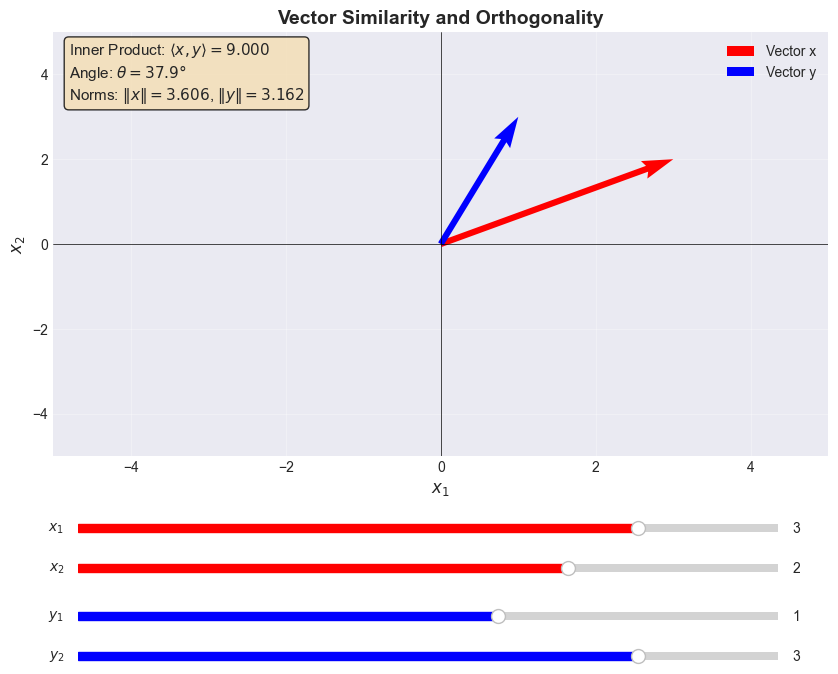

In [3]:
def interactive_vectors_sliders():
    """Interactive vector visualization using matplotlib sliders"""
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.subplots_adjust(bottom=0.35)
    
    # Initial values
    x1_init, x2_init = 3.0, 2.0
    y1_init, y2_init = 1.0, 3.0
    
    # Plot setup
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title('Vector Similarity and Orthogonality', fontsize=14, fontweight='bold')
    
    # Initial vectors
    quiver_x = ax.quiver(0, 0, x1_init, x2_init, angles='xy', scale_units='xy', 
                         scale=1, color='red', width=0.008, label='Vector x')
    quiver_y = ax.quiver(0, 0, y1_init, y2_init, angles='xy', scale_units='xy', 
                         scale=1, color='blue', width=0.008, label='Vector y')
    
    # Compute initial metrics
    def compute_metrics(x1, x2, y1, y2):
        x = np.array([x1, x2])
        y = np.array([y1, y2])
        inner_prod = np.dot(x, y)
        norm_x = np.linalg.norm(x)
        norm_y = np.linalg.norm(y)
        
        if norm_x > 1e-10 and norm_y > 1e-10:
            cos_theta = inner_prod / (norm_x * norm_y)
            cos_theta = np.clip(cos_theta, -1, 1)
            theta_deg = np.degrees(np.arccos(cos_theta))
        else:
            theta_deg = 0.0
            
        return inner_prod, theta_deg, norm_x, norm_y
    
    inner_prod, theta_deg, norm_x, norm_y = compute_metrics(x1_init, x2_init, y1_init, y2_init)
    
    # Text box for metrics
    textstr = (f'Inner Product: $\\langle x, y \\rangle = {inner_prod:.3f}$\n'
               f'Angle: $\\theta = {theta_deg:.1f}°$\n'
               f'Norms: $\\|x\\| = {norm_x:.3f}$, $\\|y\\| = {norm_y:.3f}$')
    text_box = ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper right')
    
    # Create sliders
    ax_x1 = plt.axes([0.15, 0.25, 0.7, 0.02])
    ax_x2 = plt.axes([0.15, 0.20, 0.7, 0.02])
    ax_y1 = plt.axes([0.15, 0.14, 0.7, 0.02])
    ax_y2 = plt.axes([0.15, 0.09, 0.7, 0.02])
    
    slider_x1 = Slider(ax_x1, '$x_1$', -5.0, 5.0, valinit=x1_init, color='red')
    slider_x2 = Slider(ax_x2, '$x_2$', -5.0, 5.0, valinit=x2_init, color='red')
    slider_y1 = Slider(ax_y1, '$y_1$', -5.0, 5.0, valinit=y1_init, color='blue')
    slider_y2 = Slider(ax_y2, '$y_2$', -5.0, 5.0, valinit=y2_init, color='blue')
    
    def update(val):
        x1 = slider_x1.val
        x2 = slider_x2.val
        y1 = slider_y1.val
        y2 = slider_y2.val
        
        # Update quivers
        quiver_x.set_UVC(x1, x2)
        quiver_y.set_UVC(y1, y2)
        
        # Recompute metrics
        inner_prod, theta_deg, norm_x, norm_y = compute_metrics(x1, x2, y1, y2)
        
        # Update text
        textstr = (f'Inner Product: $\\langle x, y \\rangle = {inner_prod:.3f}$\n'
                   f'Angle: $\\theta = {theta_deg:.1f}°$\n'
                   f'Norms: $\\|x\\| = {norm_x:.3f}$, $\\|y\\| = {norm_y:.3f}$')
        text_box.set_text(textstr)
        
        fig.canvas.draw_idle()
    
    slider_x1.on_changed(update)
    slider_x2.on_changed(update)
    slider_y1.on_changed(update)
    slider_y2.on_changed(update)
    
    plt.show()

# Uncomment to run the matplotlib version
interactive_vectors_sliders()

## Visualization 2: Norm Shapes

Different **p-norms** define different notions of "distance" in signal space. For a vector $x \in \mathbb{R}^2$, the p-norm is:

$$\|x\|_p = \left(\sum_{i=1}^{2} |x_i|^p\right)^{1/p}$$

Special cases:
- **$p=1$ (Manhattan/Taxicab norm)**: $\|x\|_1 = |x_1| + |x_2|$
- **$p=2$ (Euclidean norm)**: $\|x\|_2 = \sqrt{x_1^2 + x_2^2}$
- **$p=\infty$ (Chebyshev/Max norm)**: $\|x\|_\infty = \max(|x_1|, |x_2|)$

The "unit circle" for each norm is the set of all points with $\|x\|_p = 1$.

**Key Insight**: Only the $p=2$ (Euclidean) norm is **rotationally invariant**, making it the natural choice for Hilbert space geometry and signal analysis.

In [ ]:
def plot_norm_shapes():
    """Plot unit circles for different p-norms"""
    
    # Create angle array
    theta = np.linspace(0, 2*np.pi, 1000)
    
    # For p=2 (standard circle), we can use parametric form
    x_p2 = np.cos(theta)
    y_p2 = np.sin(theta)
    
    # For other p-norms, we need a different approach
    # Generate points and normalize them
    def unit_circle_p_norm(p, n_points=1000):
        """Generate points on unit circle for p-norm"""
        angles = np.linspace(0, 2*np.pi, n_points)
        x = np.cos(angles)
        y = np.sin(angles)
        
        if p == np.inf:
            # L-infinity norm: max(|x|, |y|) = 1
            # This is a square with vertices at (±1, ±1)
            t = np.linspace(0, 4, n_points)
            x = np.zeros(n_points)
            y = np.zeros(n_points)
            
            for i, ti in enumerate(t):
                if ti < 1:  # Right edge
                    x[i], y[i] = 1, -1 + 2*ti
                elif ti < 2:  # Top edge
                    x[i], y[i] = 1 - 2*(ti-1), 1
                elif ti < 3:  # Left edge
                    x[i], y[i] = -1, 1 - 2*(ti-2)
                else:  # Bottom edge
                    x[i], y[i] = -1 + 2*(ti-3), -1
        else:
            # Normalize by p-norm
            norm = (np.abs(x)**p + np.abs(y)**p)**(1/p)
            x = x / norm
            y = y / norm
        
        return x, y
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Unit "Circles" for Different p-Norms', fontsize=16, fontweight='bold')
    
    # Plot each norm
    norms = [(1, '$p=1$ (Manhattan)'), 
             (2, '$p=2$ (Euclidean)'), 
             (np.inf, '$p=\\infty$ (Chebyshev)'),
             (0.5, '$p=0.5$ (for comparison)')]
    
    for ax, (p, title) in zip(axes.flat, norms):
        if p == np.inf:
            x, y = unit_circle_p_norm(p)
        else:
            x, y = unit_circle_p_norm(p)
        
        ax.plot(x, y, linewidth=3, label=f'Unit circle: $\\|x\\|_{{{p}}} = 1$')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        
        # Add grid points to show shape better
        if p == 1:
            # Diamond shape
            ax.fill(x, y, alpha=0.2)
        elif p == 2:
            # Circle
            ax.fill(x, y, alpha=0.2)
        elif p == np.inf:
            # Square
            ax.fill(x, y, alpha=0.2)
        else:
            ax.fill(x, y, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

plot_norm_shapes()

### Demonstration: Rotational Invariance

Let's verify that only the Euclidean norm ($p=2$) is rotationally invariant:

In [ ]:
def demonstrate_rotation_invariance():
    """Show that only L2 norm is rotationally invariant"""
    
    # Original vector
    x = np.array([3, 4])
    
    # Rotation angles
    angles = np.linspace(0, 2*np.pi, 100)
    
    # Storage for norms
    norms_p1 = []
    norms_p2 = []
    norms_pinf = []
    
    for angle in angles:
        # Rotation matrix
        R = np.array([[np.cos(angle), -np.sin(angle)],
                      [np.sin(angle), np.cos(angle)]])
        
        # Rotated vector
        x_rot = R @ x
        
        # Compute different norms
        norms_p1.append(np.linalg.norm(x_rot, ord=1))
        norms_p2.append(np.linalg.norm(x_rot, ord=2))
        norms_pinf.append(np.linalg.norm(x_rot, ord=np.inf))
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(np.degrees(angles), norms_p1, label='$p=1$ (Manhattan)', linewidth=2)
    ax.plot(np.degrees(angles), norms_p2, label='$p=2$ (Euclidean)', linewidth=2)
    ax.plot(np.degrees(angles), norms_pinf, label='$p=\\infty$ (Chebyshev)', linewidth=2)
    
    ax.set_xlabel('Rotation Angle (degrees)', fontsize=12)
    ax.set_ylabel('Norm Value', fontsize=12)
    ax.set_title('Norm Values Under Rotation (Original vector: [3, 4])', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Add annotation
    ax.text(0.5, 0.95, 
            'Notice: Only the $p=2$ norm remains constant under rotation!',
            transform=ax.transAxes, fontsize=12, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Original vector: {x}")
    print(f"L1 norm range: [{np.min(norms_p1):.4f}, {np.max(norms_p1):.4f}]")
    print(f"L2 norm (constant): {norms_p2[0]:.4f}")
    print(f"L∞ norm range: [{np.min(norms_pinf):.4f}, {np.max(norms_pinf):.4f}]")

demonstrate_rotation_invariance()

## Thought Experiment: Noise, Distance, and SNR

Consider a noisy signal model:

$$y = x + \eta$$

where:
- $x$ is the clean signal
- $\eta$ is additive noise
- $y$ is the observed noisy signal

### Relationship Between Distance and SNR

The **distance** between the noisy and clean signal is:

$$\|y - x\| = \|\eta\| = \sqrt{\sum_{n} \eta^2[n]}$$

The **Signal-to-Noise Ratio (SNR)** is typically defined in dB as:

$$\text{SNR} = 10 \log_{10} \frac{\|x\|^2}{\|\eta\|^2} = 20 \log_{10} \frac{\|x\|}{\|\eta\|}$$

**Key Insight**: The distance $\|y - x\| = \|\eta\|$ is the **noise magnitude**. As SNR increases:
- The noise magnitude $\|\eta\|$ decreases
- The distance $\|y - x\|$ decreases
- The angle between $y$ and $x$ approaches 0°

Let's visualize this relationship:

In [ ]:
def visualize_snr_distance_relationship():
    """Visualize the relationship between SNR and signal distance"""
    
    # Clean signal (2D vector for visualization)
    x = np.array([4, 3])
    
    # Different noise levels (different SNRs)
    snr_db_values = [30, 20, 10, 5, 0, -5]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Left plot: Vector visualization ---
    ax1.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, 
               color='green', width=0.01, label='Clean signal $x$', zorder=5)
    
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(snr_db_values)))
    
    for i, snr_db in enumerate(snr_db_values):
        # Compute noise magnitude from SNR
        snr_linear = 10**(snr_db / 20)
        noise_magnitude = np.linalg.norm(x) / snr_linear
        
        # Generate random noise with desired magnitude
        np.random.seed(42 + i)  # For reproducibility
        eta = np.random.randn(2)
        eta = eta / np.linalg.norm(eta) * noise_magnitude
        
        # Noisy signal
        y = x + eta
        
        # Plot noisy signal
        ax1.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, 
                   color=colors[i], width=0.008, alpha=0.7,
                   label=f'$y$ (SNR={snr_db} dB)', zorder=4-i/10)
        
        # Plot noise vector
        ax1.quiver(x[0], x[1], eta[0], eta[1], angles='xy', scale_units='xy', 
                   scale=1, color=colors[i], width=0.005, alpha=0.5, 
                   linestyle='--', zorder=3)
    
    ax1.set_xlim(-2, 6)
    ax1.set_ylim(-2, 6)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)
    ax1.axvline(x=0, color='k', linewidth=0.5)
    ax1.set_xlabel('$x_1$', fontsize=12)
    ax1.set_ylabel('$x_2$', fontsize=12)
    ax1.set_title('Noisy Signal Vectors at Different SNRs', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.set_aspect('equal')
    
    # --- Right plot: SNR vs Distance ---
    snr_range = np.linspace(-10, 40, 100)
    signal_norm = np.linalg.norm(x)
    
    # Distance = noise magnitude = ||x|| / SNR_linear
    snr_linear = 10**(snr_range / 20)
    distances = signal_norm / snr_linear
    
    ax2.plot(snr_range, distances, linewidth=3, color='blue')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('SNR (dB)', fontsize=12)
    ax2.set_ylabel('Distance $\\|y - x\\| = \\|\\eta\\|$', fontsize=12)
    ax2.set_title('Relationship: SNR vs. Signal Distance', fontsize=13, fontweight='bold')
    
    # Mark the specific points
    for snr_db in snr_db_values:
        snr_lin = 10**(snr_db / 20)
        dist = signal_norm / snr_lin
        ax2.plot(snr_db, dist, 'ro', markersize=8)
        ax2.annotate(f'{snr_db} dB', xy=(snr_db, dist), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Add text box with formulas
    textstr = ('$\\mathrm{SNR_{dB}} = 20 \\log_{10}(\\|x\\|/\\|\\eta\\|)$\\n'
               '$\\|y - x\\| = \\|\\eta\\| = \\|x\\| \\cdot 10^{-\\mathrm{SNR_{dB}}/20}$')
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', 
             facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

visualize_snr_distance_relationship()

### Interactive SNR Explorer

Explore how noise affects signal geometry:

In [ ]:
def interactive_snr_explorer():
    """Interactive exploration of SNR, distance, and angle"""
    
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.subplots_adjust(bottom=0.15)
    
    # Clean signal
    x = np.array([4, 3])
    
    # Initial SNR
    snr_db_init = 10
    
    # Plot setup
    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 6)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title('Interactive SNR Explorer', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    
    # Clean signal vector
    quiver_x = ax.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', 
                         scale=1, color='green', width=0.01, label='Clean signal $x$', 
                         zorder=5)
    
    # Initial noisy signal
    snr_linear = 10**(snr_db_init / 20)
    noise_magnitude = np.linalg.norm(x) / snr_linear
    np.random.seed(42)
    eta = np.random.randn(2)
    eta = eta / np.linalg.norm(eta) * noise_magnitude
    y = x + eta
    
    quiver_y = ax.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', 
                         scale=1, color='red', width=0.01, label='Noisy signal $y$', 
                         zorder=4)
    
    quiver_eta = ax.quiver(x[0], x[1], eta[0], eta[1], angles='xy', scale_units='xy', 
                           scale=1, color='orange', width=0.006, alpha=0.7, 
                           linestyle='--', label='Noise $\\eta$', zorder=3)
    
    # Compute metrics
    distance = np.linalg.norm(eta)
    angle_rad = np.arccos(np.clip(np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y)), -1, 1))
    angle_deg = np.degrees(angle_rad)
    
    # Text box
    textstr = (f'SNR: {snr_db_init:.1f} dB\\n'
               f'Distance $\\|y-x\\|$: {distance:.3f}\\n'
               f'Angle: {angle_deg:.2f}°\\n'
               f'$\\|x\\|$: {np.linalg.norm(x):.3f}\\n'
               f'$\\|\\eta\\|$: {distance:.3f}')
    text_box = ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='lower right', fontsize=10)
    
    # Create slider
    ax_snr = plt.axes([0.15, 0.05, 0.7, 0.03])
    slider_snr = Slider(ax_snr, 'SNR (dB)', -10, 40, valinit=snr_db_init, valstep=0.5)
    
    def update(val):
        snr_db = slider_snr.val
        
        # Compute new noise
        snr_linear = 10**(snr_db / 20)
        noise_magnitude = np.linalg.norm(x) / snr_linear
        np.random.seed(42)  # Keep same noise direction
        eta = np.random.randn(2)
        eta = eta / np.linalg.norm(eta) * noise_magnitude
        y = x + eta
        
        # Update vectors
        quiver_y.set_UVC(y[0], y[1])
        quiver_eta.set_offsets([x[0], x[1]])
        quiver_eta.set_UVC(eta[0], eta[1])
        
        # Recompute metrics
        distance = np.linalg.norm(eta)
        angle_rad = np.arccos(np.clip(np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y)), -1, 1))
        angle_deg = np.degrees(angle_rad)
        
        # Update text
        textstr = (f'SNR: {snr_db:.1f} dB\\n'
                   f'Distance $\\|y-x\\|$: {distance:.3f}\\n'
                   f'Angle: {angle_deg:.2f}°\\n'
                   f'$\\|x\\|$: {np.linalg.norm(x):.3f}\\n'
                   f'$\\|\\eta\\|$: {distance:.3f}')
        text_box.set_text(textstr)
        
        fig.canvas.draw_idle()
    
    slider_snr.on_changed(update)
    
    plt.show()

# Uncomment to run
# interactive_snr_explorer()

### Numerical Experiment: SNR and Correlation

Let's quantify the relationship between SNR and the correlation (cosine of angle) between clean and noisy signals:

In [ ]:
def snr_correlation_experiment():
    """Quantify relationship between SNR and signal correlation"""
    
    # Generate a longer signal for more realistic results
    np.random.seed(123)
    n_samples = 100
    x = np.random.randn(n_samples)  # Clean signal
    
    # Range of SNR values
    snr_db_values = np.linspace(-10, 40, 50)
    
    # Storage
    correlations = []
    angles_deg = []
    distances = []
    
    for snr_db in snr_db_values:
        # Generate noise with desired SNR
        snr_linear = 10**(snr_db / 20)
        noise_power = np.var(x) / (snr_linear**2)
        eta = np.random.randn(n_samples) * np.sqrt(noise_power)
        
        # Noisy signal
        y = x + eta
        
        # Compute correlation (cosine of angle)
        correlation = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
        correlations.append(correlation)
        
        # Compute angle
        angle_rad = np.arccos(np.clip(correlation, -1, 1))
        angles_deg.append(np.degrees(angle_rad))
        
        # Compute distance
        distance = np.linalg.norm(y - x)
        distances.append(distance)
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Correlation vs SNR
    axes[0].plot(snr_db_values, correlations, linewidth=2, color='blue')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('SNR (dB)', fontsize=12)
    axes[0].set_ylabel('Correlation $\\cos(\\theta)$', fontsize=12)
    axes[0].set_title('Correlation vs. SNR', fontsize=13, fontweight='bold')
    axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Perfect correlation')
    axes[0].legend()
    
    # Plot 2: Angle vs SNR
    axes[1].plot(snr_db_values, angles_deg, linewidth=2, color='green')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('SNR (dB)', fontsize=12)
    axes[1].set_ylabel('Angle $\\theta$ (degrees)', fontsize=12)
    axes[1].set_title('Angle Between Signals vs. SNR', fontsize=13, fontweight='bold')
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero angle')
    axes[1].legend()
    
    # Plot 3: Distance vs SNR
    axes[2].semilogy(snr_db_values, distances, linewidth=2, color='red')
    axes[2].grid(True, alpha=0.3, which='both')
    axes[2].set_xlabel('SNR (dB)', fontsize=12)
    axes[2].set_ylabel('Distance $\\|y - x\\|$ (log scale)', fontsize=12)
    axes[2].set_title('Signal Distance vs. SNR', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print some key values
    print("\\nKey Observations:")
    print(f"At SNR = 0 dB: correlation = {correlations[np.argmin(np.abs(snr_db_values))]:.4f}, "
          f"angle = {angles_deg[np.argmin(np.abs(snr_db_values))]:.2f}°")
    print(f"At SNR = 20 dB: correlation = {correlations[np.argmin(np.abs(snr_db_values - 20))]:.4f}, "
          f"angle = {angles_deg[np.argmin(np.abs(snr_db_values - 20))]:.2f}°")
    print(f"\\nAs SNR → ∞: correlation → 1, angle → 0°, distance → 0")

snr_correlation_experiment()

## Summary and Key Takeaways

### Geometric Insights for Signal Processing

1. **Inner Products Measure Similarity**
   - The inner product $\langle x, y \rangle$ quantifies how "aligned" two signals are
   - Orthogonal signals ($\theta = 90°$) have zero inner product → no correlation
   - This is the basis for orthogonal transforms (Fourier, wavelets, etc.)

2. **The Euclidean Norm is Special**
   - Only the $\ell_2$ norm is rotationally invariant
   - This makes it the natural choice for defining angles and distances in signal space
   - Hilbert spaces use the $\ell_2$ norm for this reason

3. **SNR is a Geometric Quantity**
   - High SNR means the noisy signal $y$ is close to the clean signal $x$ in the signal space
   - The distance $\|y - x\| = \|\eta\|$ decreases exponentially with SNR (in dB)
   - The angle between $y$ and $x$ approaches 0 as SNR increases
   - This geometric view explains why high-SNR signals are easier to process

### Practical Implications

- **Filter Design**: Filters that preserve orthogonality (unitary transforms) don't distort the geometric relationships in signals
- **Detection Theory**: Deciding between signals is geometrically about determining which reference signal the received signal is closest to
- **Compression**: Represent signals in bases where they're sparse → most basis vectors are orthogonal to the signal
- **Estimation**: Optimal estimators (like Wiener filters) project noisy signals onto the subspace of clean signals